# 激光单光子测距：原始样本可视化与背景噪声分析

## tl;dr

- 原始数据并非严格二值：除 0/1 外，少量距离 bin 的计数为 2、3 等；距离 bin 0 在每帧几乎总有 14–16 的固定强响应，应作为硬件/近场标记剔除，而不是背景。
- dataset1 的背景显著依赖距离：0–10 km 的二值占据率约为 7%–8.5%，100–300 km 约为 0.063%–0.265%。因此不能用一个全局均匀 Bernoulli 或高斯噪声率来合成。
- 在按每个距离 bin 的经验概率校正后，相邻帧同距离命中的比例接近独立假设；但相邻距离 bin 的命中仍高于独立预期，说明应加入短距离簇噪声。
- dataset1 的部分样本具有明显帧级强度波动或掉帧（尤其样本 5 与 8）。参考集 BA0 的远场则是另一种、更接近时间独立稀疏点过程的体制，应单独作为“理想背景”场景。
- dataset1/1 与 dataset1/2 的文件 SHA-256 完全一致，不能同时作为独立训练/测试样本。

## Context & Methods

本 Notebook 将每次激光发射视为一帧，距离 bin 视为 1 m。分析重点是背景返回的时空统计，而不是在此处拟合目标轨迹。

### Key Assumptions

1. 对于 dataset1，HDF5 中的矩阵已经是 距离 bin × 帧；BA0 是 帧 × 距离 bin。下文统一按 距离 bin × 帧 的块处理。
2. 用 非零 记为一次占据事件，便于与二值轨迹检测器对应；同时保留非零数值的多重计数比例。
3. 没有目标标签的 dataset1 中，少量真实目标点会混在背景中。每帧背景约有上千个返回，目标最多一个，因此其对全局背景统计的影响很小；但局部热点不能仅凭本 Notebook 断言为背景或目标。
4. 距离 bin 0 是每帧固定的强值标记，分析时剔除。近距离 0–10 km 的强距离包络作为单独的近场杂波体制，而非与远场背景混合。
5. BA0 的 g32FinalDistance 是 1-based 索引，0 表示该帧没有参考目标点。

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import hashlib

import h5py
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.io import loadmat

RANGE_BINS = 300_000
FRAME_INTERVAL_S = 0.050
CHUNK_RANGE_BINS = 5_000
COARSE_WIDTH_M = 500
BACKGROUND_START_M = 10_000

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.sans-serif': ['DejaVu Sans', 'Arial Unicode MS', 'sans-serif'],
    'axes.unicode_minus': False,
})

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw').is_dir():
            return candidate
    raise FileNotFoundError('Cannot find data/raw from the current working directory.')

PROJECT_ROOT = find_project_root()
RAW_ROOT = PROJECT_ROOT / 'data' / 'raw'
REFERENCE_ROOT = RAW_ROOT / 'dataset260707' / '260707原始数据及结果参考'
REFERENCE_LABEL_PATH = REFERENCE_ROOT / 'g32FinalDistance.mat'

print(f'Project root: {PROJECT_ROOT}')
print(f'Raw data root: {RAW_ROOT}')

Project root: /home/pc5090/Code/github/LineTracker
Raw data root: /home/pc5090/Code/github/LineTracker/data/raw


## Data

先建立样本目录和统一的流式读取接口。dataset1 是 MATLAB v7.3/HDF5，不能用 scipy.io.loadmat 直接读取；BA0 是普通 MAT 文件。

In [2]:
def sha256_file(path: Path, block_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        while block := handle.read(block_size):
            digest.update(block)
    return digest.hexdigest()

def find_hdf5_matrix(path: Path) -> tuple[str, tuple[int, int]]:
    candidates: list[tuple[str, tuple[int, int]]] = []
    with h5py.File(path, 'r') as handle:
        def visitor(name: str, node: h5py.Dataset | h5py.Group) -> None:
            if isinstance(node, h5py.Dataset) and node.ndim == 2 and RANGE_BINS in node.shape:
                candidates.append((name, tuple(node.shape)))
        handle.visititems(visitor)
    if len(candidates) != 1:
        raise ValueError(f'Expected one {RANGE_BINS}-bin matrix in {path}, found {candidates}.')
    return candidates[0]

def inspect_matrix(path: Path) -> dict:
    if h5py.is_hdf5(path):
        variable, shape = find_hdf5_matrix(path)
        is_hdf5 = True
        storage = 'MATLAB v7.3 / HDF5'
    else:
        mat = loadmat(path)
        candidates = [
            (name, np.asarray(value).shape)
            for name, value in mat.items()
            if not name.startswith('__')
            and isinstance(value, np.ndarray)
            and np.asarray(value).ndim == 2
            and RANGE_BINS in np.asarray(value).shape
        ]
        if len(candidates) != 1:
            raise ValueError(f'Expected one {RANGE_BINS}-bin matrix in {path}, found {candidates}.')
        variable, shape = candidates[0]
        is_hdf5 = False
        storage = 'MATLAB v5'
    if shape[0] == RANGE_BINS:
        layout = 'range × frame'
        frames = shape[1]
    else:
        layout = 'frame × range'
        frames = shape[0]
    return {
        'variable': variable,
        'shape': shape,
        'frames': int(frames),
        'layout': layout,
        'storage': storage,
        'is_hdf5': is_hdf5,
    }

dataset1_paths = sorted(
    (RAW_ROOT / 'dataset1').rglob('*.mat'),
    key=lambda path: int(path.parent.name),
)
raw_paths = [*dataset1_paths, REFERENCE_ROOT / 'BA0.mat']

catalog_rows = []
for path in raw_paths:
    info = inspect_matrix(path)
    if path.name == 'BA0.mat':
        sample_id = 'reference/BA0'
        source_group = 'reference'
    else:
        sample_id = f'dataset1/{path.parent.name}'
        source_group = 'dataset1'
    catalog_rows.append({
        'sample_id': sample_id,
        'source_group': source_group,
        'path': path,
        'relative_path': str(path.relative_to(PROJECT_ROOT)),
        'sha256': sha256_file(path),
        **info,
    })

catalog = pd.DataFrame(catalog_rows)
display(catalog[['sample_id', 'storage', 'variable', 'shape', 'layout', 'frames', 'relative_path']])

duplicate_rows = catalog[catalog.duplicated('sha256', keep=False)]
if duplicate_rows.empty:
    print('No byte-identical raw arrays found.')
else:
    display(Markdown('### Byte-identical raw arrays'))
    display(duplicate_rows[['sample_id', 'sha256', 'relative_path']])

,sample_id,storage,variable,shape,layout,frames,relative_path
0,dataset1/1,MATLAB v7.3 / HDF5,total_chs,"(300000, 384)",range × frame,384,data/raw/dataset1/1/total_ch27_data.mat
1,dataset1/2,MATLAB v7.3 / HDF5,total_chs,"(300000, 384)",range × frame,384,data/raw/dataset1/2/total_ch27_data.mat
2,dataset1/3,MATLAB v7.3 / HDF5,total_chs,"(300000, 146)",range × frame,146,data/raw/dataset1/3/total_ch27_data.mat
3,dataset1/4,MATLAB v7.3 / HDF5,total_chs,"(300000, 510)",range × frame,510,data/raw/dataset1/4/total_ch28_data.mat
4,dataset1/5,MATLAB v7.3 / HDF5,total_chs,"(300000, 768)",range × frame,768,data/raw/dataset1/5/total_ch28_data.mat
5,dataset1/6,MATLAB v7.3 / HDF5,total_chs,"(300000, 382)",range × frame,382,data/raw/dataset1/6/total_ch28_data.mat
6,dataset1/7,MATLAB v7.3 / HDF5,total_chs,"(300000, 448)",range × frame,448,data/raw/dataset1/7/total_ch27_data.mat
7,dataset1/8,MATLAB v7.3 / HDF5,total_chs,"(300000, 510)",range × frame,510,data/raw/dataset1/8/total_ch27_data.mat
8,dataset1/9,MATLAB v7.3 / HDF5,total_chs,"(300000, 256)",range × frame,256,data/raw/dataset1/9/total_ch27_data.mat
9,dataset1/10,MATLAB v7.3 / HDF5,total_chs,"(300000, 319)",range × frame,319,data/raw/dataset1/10/total_ch27_data.mat


### Byte-identical raw arrays

,sample_id,sha256,relative_path
0,dataset1/1,1dea37996415f5fe482547b7d04429c9b22c51baeb6e56...,data/raw/dataset1/1/total_ch27_data.mat
1,dataset1/2,1dea37996415f5fe482547b7d04429c9b22c51baeb6e56...,data/raw/dataset1/2/total_ch27_data.mat


In [3]:
def iter_range_by_frame_blocks(record: dict, chunk_range_bins: int = CHUNK_RANGE_BINS):
    '''Yield (range_start, values) where values has shape (range, frame).'''
    path = Path(record['path'])
    if record['is_hdf5']:
        with h5py.File(path, 'r') as handle:
            dataset = handle[record['variable']]
            for start in range(0, RANGE_BINS, chunk_range_bins):
                yield start, np.asarray(dataset[start:start + chunk_range_bins, :])
    else:
        array = np.asarray(loadmat(path, variable_names=[record['variable']])[record['variable']])
        for start in range(0, RANGE_BINS, chunk_range_bins):
            yield start, array[:, start:start + chunk_range_bins].T

def read_range_window(record: dict, start_m: int, stop_m: int) -> np.ndarray:
    '''Return a small window with shape (frame, range).'''
    path = Path(record['path'])
    if record['is_hdf5']:
        with h5py.File(path, 'r') as handle:
            return np.asarray(handle[record['variable']][start_m:stop_m, :]).T
    array = np.asarray(loadmat(path, variable_names=[record['variable']])[record['variable']])
    return array[:, start_m:stop_m]

def contiguous_runs(indices: np.ndarray) -> list[tuple[int, int]]:
    if len(indices) == 0:
        return []
    splits = np.where(np.diff(indices) != 1)[0] + 1
    return [(int(group[0]), int(group[-1])) for group in np.split(indices, splits)]

REGIONS = [
    (1, 10_000, '0–10 km'),
    (10_000, 50_000, '10–50 km'),
    (50_000, 100_000, '50–100 km'),
    (100_000, 200_000, '100–200 km'),
    (200_000, 300_000, '200–300 km'),
]

def profile_sample(record: dict, coarse_width_m: int = COARSE_WIDTH_M) -> dict:
    n_frames = record['frames']
    frame_counts = np.zeros(n_frames, dtype=np.int64)
    range_counts = np.zeros(RANGE_BINS, dtype=np.int64)
    coarse_counts = np.zeros((n_frames, RANGE_BINS // coarse_width_m), dtype=np.uint16)
    value_counts = Counter()
    marker_counts = Counter()
    temporal_pairs = 0
    spatial_pairs = 0
    previous_last_row = None
    background_temporal_pairs = 0
    background_spatial_pairs = 0
    background_previous_last_row = None

    for start, raw_block in iter_range_by_frame_blocks(record):
        block = np.asarray(raw_block)
        if start == 0:
            marker_values, marker_n = np.unique(block[0], return_counts=True)
            marker_counts.update({int(v): int(n) for v, n in zip(marker_values, marker_n)})
            block = block.copy()
            block[0, :] = 0

        occupied = block > 0
        frame_counts += occupied.sum(axis=0, dtype=np.int64)
        range_counts[start:start + occupied.shape[0]] = occupied.sum(axis=1, dtype=np.int64)

        values, counts = np.unique(block[occupied], return_counts=True)
        value_counts.update({int(v): int(n) for v, n in zip(values, counts)})

        temporal_pairs += int(np.count_nonzero(occupied[:, 1:] & occupied[:, :-1]))
        if previous_last_row is not None:
            spatial_pairs += int(np.count_nonzero(previous_last_row & occupied[0]))
        spatial_pairs += int(np.count_nonzero(occupied[1:, :] & occupied[:-1, :]))
        previous_last_row = occupied[-1].copy()

        background_start = max(0, BACKGROUND_START_M - start)
        background_block = occupied[background_start:, :]
        if background_block.size:
            background_temporal_pairs += int(
                np.count_nonzero(background_block[:, 1:] & background_block[:, :-1])
            )
            if background_previous_last_row is not None:
                background_spatial_pairs += int(
                    np.count_nonzero(background_previous_last_row & background_block[0])
                )
            background_spatial_pairs += int(
                np.count_nonzero(background_block[1:, :] & background_block[:-1, :])
            )
            background_previous_last_row = background_block[-1].copy()

        if occupied.shape[0] % coarse_width_m:
            raise ValueError('Chunk size must align with coarse_width_m.')
        group_start = start // coarse_width_m
        group_stop = group_start + occupied.shape[0] // coarse_width_m
        coarse_counts[:, group_start:group_stop] = (
            occupied.reshape(-1, coarse_width_m, n_frames).sum(axis=1).T
        )

    probability_by_range = range_counts / n_frames
    # For same-bin temporal pairs, k(k-1)/F is the unbiased estimator of
    # (F-1) p(r)^2 when a bin is observed in k of F frames.
    expected_temporal_pairs = np.sum(range_counts * (range_counts - 1)) / n_frames
    expected_spatial_pairs = n_frames * np.dot(probability_by_range[:-1], probability_by_range[1:])
    background_counts = range_counts[BACKGROUND_START_M:]
    background_probability = probability_by_range[BACKGROUND_START_M:]
    expected_background_temporal_pairs = np.sum(
        background_counts * (background_counts - 1)
    ) / n_frames
    expected_background_spatial_pairs = n_frames * np.dot(
        background_probability[:-1], background_probability[1:]
    )
    total_events = int(range_counts.sum())
    multi_event_fraction = (
        sum(count for value, count in value_counts.items() if value > 1) / total_events
    )

    region_rates = {
        label: range_counts[left:right].sum() / ((right - left) * n_frames)
        for left, right, label in REGIONS
    }
    median_count = float(np.median(frame_counts))
    low_frame_runs = contiguous_runs(np.flatnonzero(frame_counts < 0.5 * median_count))

    return {
        'record': record,
        'frame_counts': frame_counts,
        'range_counts': range_counts,
        'coarse_counts': coarse_counts,
        'value_counts': value_counts,
        'marker_counts': marker_counts,
        'total_events': total_events,
        'mean_events_per_frame': float(frame_counts.mean()),
        'fano_factor': float(frame_counts.var(ddof=1) / frame_counts.mean()),
        'multi_event_fraction': float(multi_event_fraction),
        'region_rates': region_rates,
        'temporal_pair_ratio': float(temporal_pairs / expected_temporal_pairs),
        'spatial_pair_ratio': float(spatial_pairs / expected_spatial_pairs),
        'background_temporal_pair_ratio': float(
            background_temporal_pairs / expected_background_temporal_pairs
        ),
        'background_spatial_pair_ratio': float(
            background_spatial_pairs / expected_background_spatial_pairs
        ),
        'low_frame_runs': low_frame_runs,
    }

## Results

### 1. Per-sample event profile

以下统计按二值占据事件计算，且已剔除距离 bin 0。时空相邻对比值在 10 km 以上背景域计算，分母使用每个距离 bin 的经验概率 p(r)：接近 1 表示在已知距离包络后近似独立；大于 1 表示额外的聚集。时间相邻对的期望采用 k(k−1)/F 的无偏估计，避免用有限帧样本直接平方 p(r) 所带来的正偏差。

In [4]:
records = catalog.to_dict('records')
profiles = {record['sample_id']: profile_sample(record) for record in records}

summary_rows = []
for record in records:
    profile = profiles[record['sample_id']]
    summary_rows.append({
        'sample': record['sample_id'],                          # 样本名，例如 dataset1/1、reference/BA0
        'frames': record['frames'],                             # 该样本包含的激光发射帧数；每帧间隔 50 ms
        'events/frame': profile['mean_events_per_frame'],       # 平均每帧非零距离 bin 数；已剔除 range bin 0 的固定硬件强响应（此处把 raw_value > 0 视为一个二值事件）
        'Fano': profile['fano_factor'],                         # 每帧事件数的方差 / 均值。理想泊松过程约为 1；明显大于 1 说明帧间强度波动、突发噪声或掉帧
        '0–10 km p': profile['region_rates']['0–10 km'],        # 0–10 km 内任意一个 1 m bin 在任一帧中为非零的平均概率
        '100–300 km p': (
            profile['region_rates']['100–200 km'] * 100_000
            + profile['region_rates']['200–300 km'] * 100_000
        ) / 200_000,                                            # 100–300 km 的平均单-bin占据概率。两段各宽 100 km，故按 bin 数加权；这里也等价于两段概率的算术平均
        'multi-count events': profile['multi_event_fraction'],  # 在所有非零 bin 中，raw value > 1 的比例，用于衡量原始数据偏离严格二值的程度

        'temporal pair / expected (≥10 km)': profile['background_temporal_pair_ratio'],
        # 10 km 以上，相同距离 bin 在相邻两帧都命中的次数 / 按该 bin 的经验 p(r) 推导出的独立期望
        # ≈1：时间上近似独立；>1：正时间相关；<1：负相关或交替出现

        'spatial pair / expected (≥10 km)': profile['background_spatial_pair_ratio'],
        # 10 km 以上，相邻两个距离 bin 在同一帧同时命中的次数 / 独立期望
        # >1：存在空间簇噪声；例如一个响应容易扩展到相邻 1–3 m bin

        'low-count frame runs': profile['low_frame_runs'],      # 连续低计数帧区间；判定条件是该帧事件数 < 本样本帧计数中位数的 50%。元组 (start, end) 为从 0 开始的帧索引
    })
summary = pd.DataFrame(summary_rows)

summary_display = summary.copy()
for column in ['events/frame', 'Fano', '0–10 km p', '100–300 km p',
               'multi-count events', 'temporal pair / expected (≥10 km)', 'spatial pair / expected (≥10 km)']:
    summary_display[column] = summary_display[column].map(lambda value: f'{value:.5g}')
display(summary_display)

unique_catalog = catalog.drop_duplicates('sha256', keep='first')
unique_dataset1_ids = unique_catalog.loc[
    unique_catalog['source_group'].eq('dataset1'), 'sample_id'
].tolist()
print(f'Independent dataset1 files after deduplication: {len(unique_dataset1_ids)}')
print(f'Unique dataset1 ids: {unique_dataset1_ids}')

,sample,frames,events/frame,Fano,0–10 km p,100–300 km p,multi-count events,temporal pair / expected (≥10 km),spatial pair / expected (≥10 km),low-count frame runs
0,dataset1/1,384,1559.4,1.9121,0.073979,0.0019038,0.037049,1.0488,1.7899,[]
1,dataset1/2,384,1559.4,1.9121,0.073979,0.0019038,0.037049,1.0488,1.7899,[]
2,dataset1/3,146,1680.9,1.5493,0.073144,0.0022931,0.036466,1.0548,1.5735,[]
3,dataset1/4,510,1686.5,1.7595,0.073607,0.002623,0.034611,1.0863,2.2591,[]
4,dataset1/5,768,1582.5,57.998,0.069521,0.0024815,0.034495,1.0672,2.3388,"[(38, 54), (758, 766)]"
5,dataset1/6,382,1132.4,1.9177,0.064335,0.00081613,0.038628,0.99245,1.5664,[]
6,dataset1/7,448,1034.6,1.4985,0.064361,0.0006767,0.039915,1.032,1.7978,[]
7,dataset1/8,510,1038.5,82.945,0.060486,0.0007617,0.040541,1.1051,1.9581,"[(472, 509)]"
8,dataset1/9,256,1187.4,1.3713,0.067093,0.0011505,0.039277,1.0498,1.9408,[]
9,dataset1/10,319,1211.6,1.4263,0.067505,0.0012266,0.038664,1.0435,1.8209,[]


Independent dataset1 files after deduplication: 9
Unique dataset1 ids: ['dataset1/1', 'dataset1/3', 'dataset1/4', 'dataset1/5', 'dataset1/6', 'dataset1/7', 'dataset1/8', 'dataset1/9', 'dataset1/10']


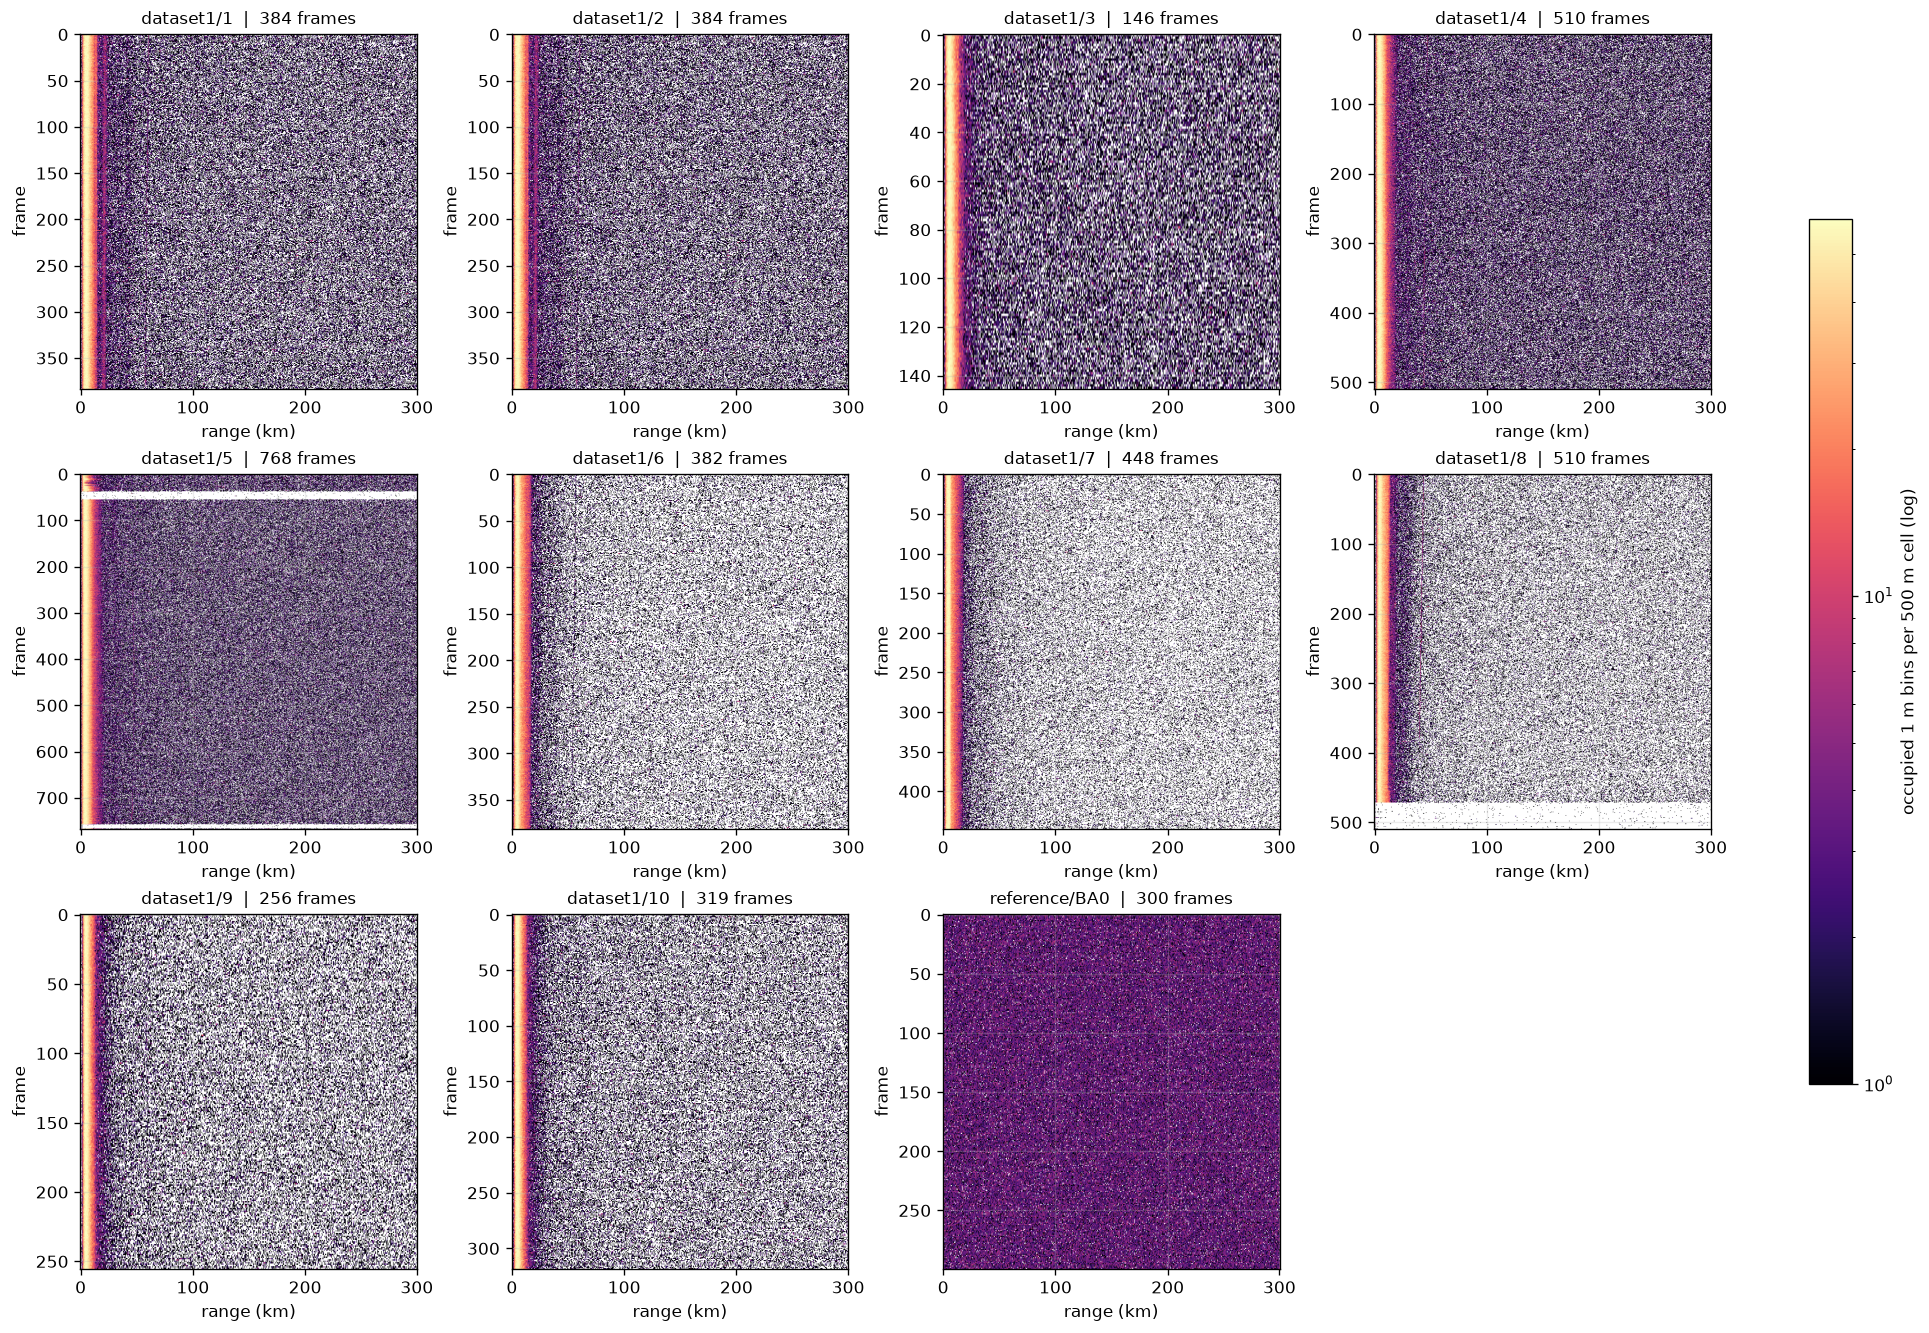

In [5]:
# Every raw array is shown below.  Each pixel is the number of occupied 1 m bins
# after aggregating 500 m in range; a logarithmic scale retains both near and far returns.
ordered_ids = catalog['sample_id'].tolist()
all_positive_coarse = np.concatenate([
    profiles[sample_id]['coarse_counts'][profiles[sample_id]['coarse_counts'] > 0]
    for sample_id in ordered_ids
])
vmax = max(2, int(np.quantile(all_positive_coarse, 0.995)))
norm = mcolors.LogNorm(vmin=1, vmax=vmax)
cmap = plt.get_cmap('magma').copy()
cmap.set_bad('white')

fig, axes = plt.subplots(3, 4, figsize=(16, 11), constrained_layout=True)
for axis, sample_id in zip(axes.flat, ordered_ids):
    profile = profiles[sample_id]
    image = np.ma.masked_equal(profile['coarse_counts'], 0)
    plot = axis.imshow(image, origin='upper', aspect='auto', cmap=cmap, norm=norm)
    axis.set_title(f'{sample_id}  |  {profile["record"]["frames"]} frames', fontsize=10)
    axis.set_xlabel('range (km)')
    axis.set_ylabel('frame')
    axis.set_xticks([0, 200, 400, 599], ['0', '100', '200', '300'])
for axis in axes.flat[len(ordered_ids):]:
    axis.axis('off')
fig.colorbar(plot, ax=axes.ravel().tolist(), shrink=0.70, label='occupied 1 m bins per 500 m cell (log)')
plt.show()

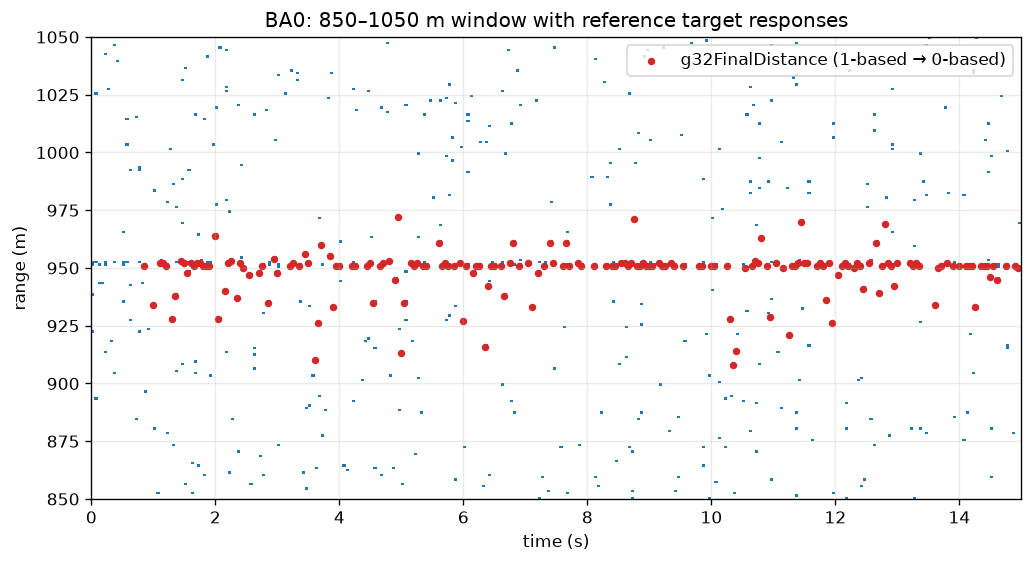

Reference labels: 182 detected frames, 118 explicit missed-detection frames; 182/182 labels coincide with a nonzero raw return.


In [6]:
# BA0 是唯一一个附带参考目标距离序列的数据集。它验证了方向性，并使目标丢失情况变得可见
reference_record = next(record for record in records if record['sample_id'] == 'reference/BA0')
reference_labels = loadmat(REFERENCE_LABEL_PATH)['g32FinalDistance'].ravel().astype(int)
window_start_m, window_stop_m = 850, 1_050
window = read_range_window(reference_record, window_start_m, window_stop_m) > 0
valid_labels = reference_labels > 0
label_ranges_m = reference_labels[valid_labels] - 1
label_frames = np.flatnonzero(valid_labels)
inside_window = (label_ranges_m >= window_start_m) & (label_ranges_m < window_stop_m)
label_hits = window[label_frames[inside_window], label_ranges_m[inside_window] - window_start_m]

fig, axis = plt.subplots(figsize=(10, 5))
axis.scatter(
    label_frames[inside_window] * FRAME_INTERVAL_S,
    label_ranges_m[inside_window],
    s=12,
    color='#d62728',
    label='g32FinalDistance (1-based → 0-based)',
)
axis.imshow(
    window.T,
    origin='lower',
    interpolation='nearest',
    aspect='auto',
    cmap=mcolors.ListedColormap(['white', '#1f77b4']),
    extent=(0, reference_record['frames'] * FRAME_INTERVAL_S, window_start_m, window_stop_m),
)
axis.set(
    title='BA0: 850–1050 m window with reference target responses',
    xlabel='time (s)',
    ylabel='range (m)',
)
axis.legend(loc='upper right')
plt.show()

print(
    f'Reference labels: {valid_labels.sum()} detected frames, '
    f'{(~valid_labels).sum()} explicit missed-detection frames; '
    f'{label_hits.sum()}/{len(label_hits)} labels coincide with a nonzero raw return.'
)

def plot_range_window(sample_id: str, start_m: int, stop_m: int) -> None:
    '''Convenience view for inspecting a selected sample at full range resolution.'''
    record = next(item for item in records if item['sample_id'] == sample_id)
    values = read_range_window(record, start_m, stop_m) > 0
    fig, axis = plt.subplots(figsize=(11, 4))
    axis.imshow(values.T, origin='lower', aspect='auto', interpolation='nearest',
                cmap=mcolors.ListedColormap(['white', '#1f77b4']),
                extent=(0, record['frames'] * FRAME_INTERVAL_S, start_m, stop_m))
    axis.set(title=f'{sample_id}: {start_m}–{stop_m} m', xlabel='time (s)', ylabel='range (m)')
    plt.show()

# Example for a closer look: 
# plot_range_window('dataset1/1', 0, 20_000)

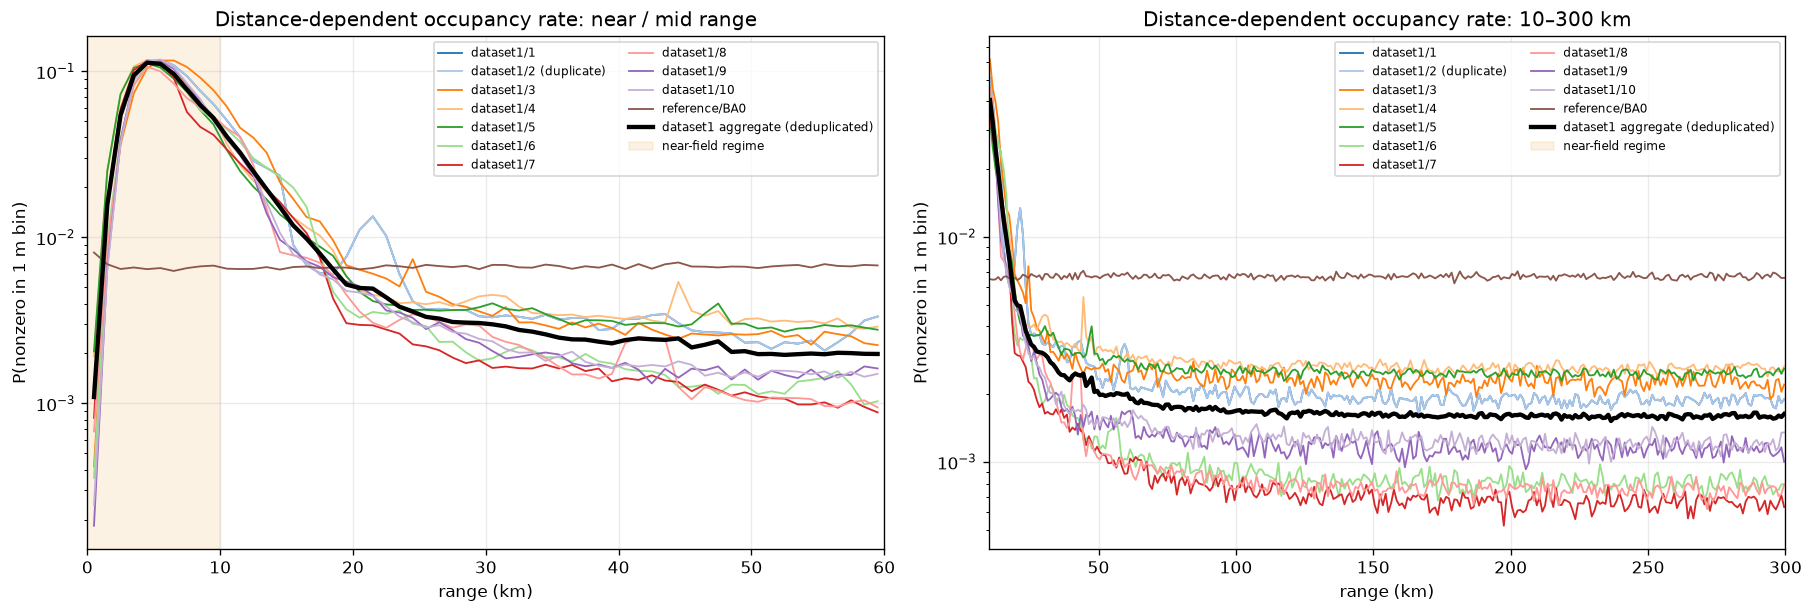

In [7]:
def grouped_range_rate(profile: dict, width_m: int = 1_000) -> np.ndarray:
    '''把 30 万个 1 m bin 按每 1 km 合并.'''
    counts = profile['range_counts'].reshape(-1, width_m).sum(axis=1)   # 每个 1 km 区间内、所有帧累计的非零命中数
    return counts / (width_m * profile['record']['frames'])             

centres_km = (np.arange(RANGE_BINS // 1_000) + 0.5)     
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
colors = plt.get_cmap('tab20').colors

for index, sample_id in enumerate(ordered_ids):
    rates = grouped_range_rate(profiles[sample_id])
    label = sample_id + (' (duplicate)' if sample_id == 'dataset1/2' else '')
    axes[0].semilogy(centres_km[:60], rates[:60], color=colors[index % len(colors)], lw=1.1, label=label)
    axes[1].semilogy(centres_km[10:], rates[10:], color=colors[index % len(colors)], lw=1.1, label=label)

unique_range_counts = np.add.reduce([profiles[sample_id]['range_counts'] for sample_id in unique_dataset1_ids])
unique_frame_total = sum(profiles[sample_id]['record']['frames'] for sample_id in unique_dataset1_ids)
aggregate_rates = unique_range_counts.reshape(-1, 1_000).sum(axis=1) / (1_000 * unique_frame_total)
axes[0].semilogy(centres_km[:60], aggregate_rates[:60], color='black', lw=2.6, label='dataset1 aggregate (deduplicated)')
axes[1].semilogy(centres_km[10:], aggregate_rates[10:], color='black', lw=2.6, label='dataset1 aggregate (deduplicated)')

for axis, title, xlim in [
    (axes[0], 'Distance-dependent occupancy rate: near / mid range', (0, 60)),
    (axes[1], 'Distance-dependent occupancy rate: 10–300 km', (10, 300)),
]:
    axis.axvspan(0, 10, color='#f0ad4e', alpha=0.15, label='near-field regime')
    axis.set(title=title, xlabel='range (km)', ylabel='P(nonzero in 1 m bin)')
    axis.set_xlim(*xlim)
    axis.legend(fontsize=7, ncol=2)
plt.show()

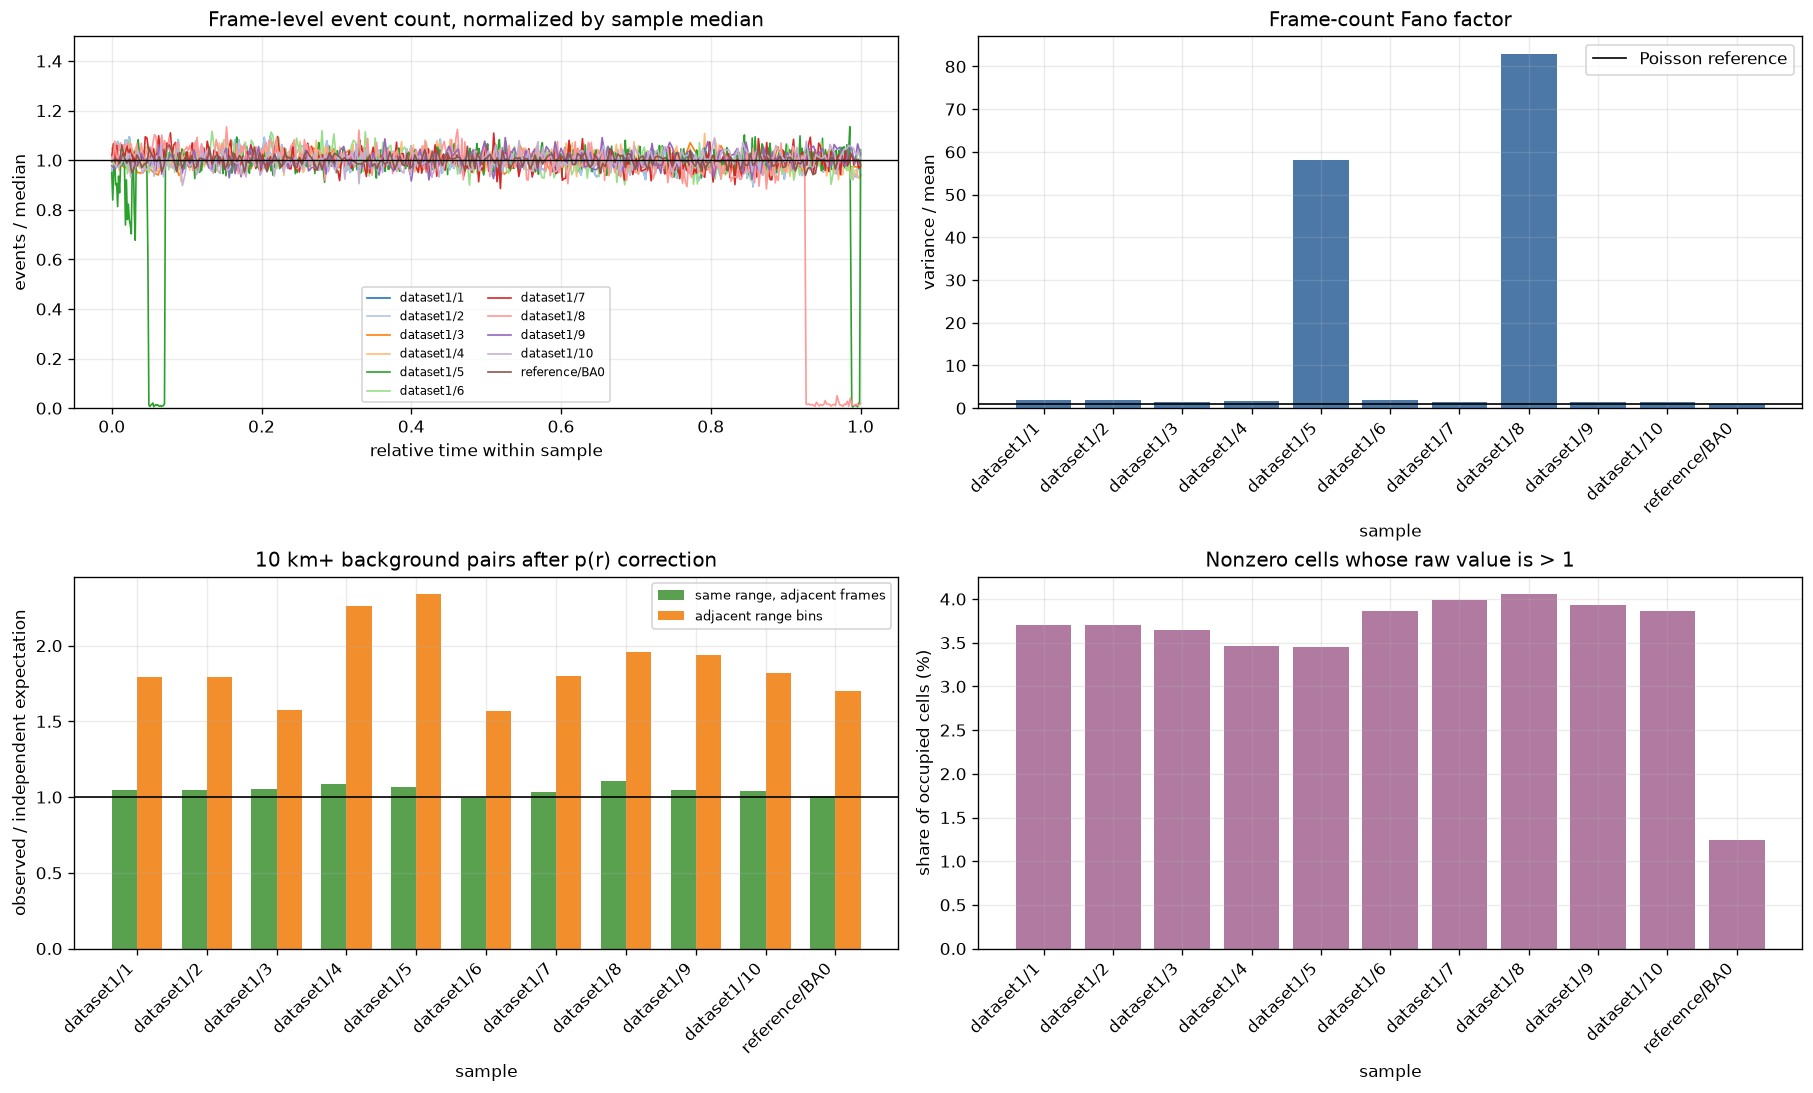

,sample,P(value=1 | nonzero),P(value≥2 | nonzero),largest observed value,bin-0 marker values
0,dataset1/1,0.962951,0.037049,5,{16: 384}
1,dataset1/2,0.962951,0.037049,5,{16: 384}
2,dataset1/3,0.963534,0.036466,6,{16: 146}
3,dataset1/4,0.965389,0.034611,11,"{15: 2, 16: 508}"
4,dataset1/5,0.965505,0.034495,6,"{14: 8, 15: 6, 16: 754}"
5,dataset1/6,0.961372,0.038628,5,"{15: 1, 16: 381}"
6,dataset1/7,0.960085,0.039915,6,{16: 448}
7,dataset1/8,0.959459,0.040541,5,"{13: 4, 14: 10, 15: 15, 16: 481}"
8,dataset1/9,0.960723,0.039277,5,{16: 256}
9,dataset1/10,0.961336,0.038664,5,{16: 319}


In [8]:
# 这一单元从四个角度检查背景噪声：
# 1) 每帧总命中数是否稳定；2) 帧级波动是否像泊松过程；
# 3) 10 km 以上背景是否具有时空相关；4) 原始数据偏离二值的程度。

# labels 用于四个柱状图的样本名称；x 是每个样本的柱子横坐标。
labels = summary['sample'].tolist()
x = np.arange(len(labels))

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

# ---- 左上：每帧总事件数的相对变化 ----
# 各样本帧数不同，因此把时间轴缩放为 [0, 1]，便于把曲线叠加比较。
# 每帧事件数再除以本样本的中位数；正常背景应围绕 1 上下波动。
# 突然接近 0 的连续片段通常意味着掉帧、门控变化或背景骤降。
for index, sample_id in enumerate(ordered_ids):
    frame_counts = profiles[sample_id]['frame_counts']
    normalized_time = np.linspace(0, 1, len(frame_counts))
    axes[0, 0].plot(
        normalized_time,
        frame_counts / np.median(frame_counts),
        lw=1.0,
        color=colors[index % len(colors)],
        label=sample_id,
    )
axes[0, 0].axhline(1, color='black', lw=0.8)  # 中位数基准线
axes[0, 0].set(
    title='Frame-level event count, normalized by sample median',
    xlabel='relative time within sample',
    ylabel='events / median',
    ylim=(0, 1.5),  # 强调低计数和正常波动；极高异常值不作为本图重点
)
axes[0, 0].legend(fontsize=7, ncol=2)

# ---- 右上：Fano factor，量化每帧总事件数的离散程度 ----
# Fano = Var(N_frame) / Mean(N_frame)。
# 理想泊松计数的 Fano 约为 1；明显大于 1 表示帧级强度不稳定或存在突发/掉帧。
axes[0, 1].bar(x, summary['Fano'], color='#4c78a8')
axes[0, 1].axhline(1, color='black', lw=1, label='Poisson reference')
axes[0, 1].set(title='Frame-count Fano factor', xlabel='sample', ylabel='variance / mean')
axes[0, 1].set_xticks(x, labels, rotation=45, ha='right')
axes[0, 1].legend()

# ---- 左下：10 km 以上背景的局部相关性 ----
# 绿色：同一个距离 bin 在相邻两帧同时为非零的次数 / 时间独立期望。
# 橙色：同一帧中相邻两个距离 bin 同时为非零的次数 / 空间独立期望。
# 两项均已用各距离 bin 的 p(r) 校正，因此 1 是“独立背景”基准。
# 绿色 > 1 表示时间持续性；橙色 > 1 表示 1–3 m 等短距离簇噪声。
axes[1, 0].bar(
    x - 0.18,
    summary['temporal pair / expected (≥10 km)'],
    width=0.36,
    label='same range, adjacent frames',
    color='#59a14f',
)
axes[1, 0].bar(
    x + 0.18,
    summary['spatial pair / expected (≥10 km)'],
    width=0.36,
    label='adjacent range bins',
    color='#f28e2b',
)
axes[1, 0].axhline(1, color='black', lw=1)  # 独立期望
axes[1, 0].set(
    title='10 km+ background pairs after p(r) correction',
    xlabel='sample',
    ylabel='observed / independent expectation',
)
axes[1, 0].set_xticks(x, labels, rotation=45, ha='right')
axes[1, 0].legend(fontsize=8)

# ---- 右下：原始计数不是严格二值的比例 ----
# 这里统计“已占据的 bin 中，原始值大于 1”的占比。
# 如果后续仿真只使用 0/1，可忽略该项；若要保留光子计数，应拟合该条件分布。
axes[1, 1].bar(x, 100 * summary['multi-count events'], color='#b07aa1')
axes[1, 1].set(
    title='Nonzero cells whose raw value is > 1',
    xlabel='sample',
    ylabel='share of occupied cells (%)',
)
axes[1, 1].set_xticks(x, labels, rotation=45, ha='right')
plt.show()

# ---- 原始计数的条件分布摘要表 ----
# P(value=1 | nonzero) 与 P(value≥2 | nonzero) 的条件是该 bin 已经非零。
# largest observed value 用来识别偶发的大计数；
# bin-0 marker values 显示被剔除的距离 bin 0 固定硬件/近场标记的取值。
multiplicity_rows = []
for sample_id in ordered_ids:
    value_counts = profiles[sample_id]['value_counts']
    total = sum(value_counts.values())
    multiplicity_rows.append({
        'sample': sample_id,
        'P(value=1 | nonzero)': value_counts[1] / total,
        'P(value≥2 | nonzero)': sum(
            n for value, n in value_counts.items() if value >= 2
        ) / total,
        'largest observed value': max(value_counts),
        'bin-0 marker values': dict(
            sorted(profiles[sample_id]['marker_counts'].items())
        ),
    })
multiplicity = pd.DataFrame(multiplicity_rows)
display(multiplicity)

## 结论与建议

### 数据支持的结论

1. 不应把 BA0 与 dataset1 混合拟合为一个背景分布。BA0 的 10 km 以上区域可作为近似均匀、时间近似独立的参考背景；dataset1 则存在明显的距离衰减、样本间底噪差异和空间聚集。

2. dataset1/1 与 dataset1/2 完全重复。构建常规背景场景时，建议使用独立的稳定样本：dataset1/1、3、4、6、7、9、10；样本 5、8 的连续低计数段应单独作为掉帧/异常接收的压力测试场景。

3. 对于二值数据，背景的核心参数是每个距离 bin 的命中概率，而不是整个 300 km 区间的总光子数。对场景 $j$ 的距离 bin $r$，定义：

$$
p_{j,r}
=
\frac{\text{该样本中距离 }r\text{ 非零的帧数}}
{\text{该样本总帧数}}.
$$

其中 $r=0,1,\ldots,299999$，每个 $r$ 对应 1 m；$j$ 表示选定的背景样本或工况。

4. dataset1 的 $p_{j,r}$ 明显随距离变化：近场 0–10 km 的概率远高于远场。因此，不能使用一个全局固定概率生成全部距离 bin。距离至少应区分近场、过渡区和远场；bin 0 的固定强响应应始终屏蔽或独立处理。

5. 在 10 km 以上背景域中，经距离概率 $p(r)$ 校正后，同一距离 bin 的相邻帧命中基本接近独立；但相邻距离 bin 的同时命中仍高于独立期望。因此，背景应以独立 Bernoulli 点为主，并加入少量 1–3 m 的空间簇噪声。

### 二值背景合成方案

对选定场景 $j$，先计算逐 1 m 的经验命中概率：

$$
p_{j,r}
=
\frac{\mathrm{range\_counts}_{j,r}}{F_j},
$$

其中 $F_j$ 为样本帧数。生成第 $t$ 帧背景时：

$$
B_{t,r}\sim\mathrm{Bernoulli}(p_{j,r}).
$$


In [9]:
# Compact, data-derived parameter handoff for a future synthetic-data generator.
# Gamma shape is only a moment-matched approximation; bootstrapping normalized
# frame counts is preferable when the sample contains explicit dropout runs.
scenario_rows = []
for sample_id in ordered_ids:
    profile = profiles[sample_id]
    mean = profile['mean_events_per_frame']
    fano = profile['fano_factor']
    gamma_shape = np.inf if fano <= 1 else mean / (fano - 1)
    scenario_rows.append({
        'scenario': sample_id,
        'mean events/frame': mean,
        'Fano': fano,
        'Gamma shape (approx.)': gamma_shape,
        'p_bar(0–10 km)': profile['region_rates']['0–10 km'],
        'p_bar(10–50 km)': profile['region_rates']['10–50 km'],
        'p_bar(100–300 km)': (
            profile['region_rates']['100–200 km'] + profile['region_rates']['200–300 km']
        ) / 2,
        '10 km+ spatial-pair excess': profile['background_spatial_pair_ratio'],
        'dropout runs (<50% median)': profile['low_frame_runs'],
    })
scenario_table = pd.DataFrame(scenario_rows)
display(scenario_table)

dataset1_profiles = [profiles[sample_id] for sample_id in unique_dataset1_ids]
near_rate = np.mean([item['region_rates']['0–10 km'] for item in dataset1_profiles])
far_rate = np.mean([
    (item['region_rates']['100–200 km'] + item['region_rates']['200–300 km']) / 2
    for item in dataset1_profiles
])
display(Markdown(
    '\n'.join([
        '### Data-derived conclusion',
        f'- Deduplicated dataset1 mean near-field occupancy: **{near_rate:.4%}** per 1 m bin.',
        f'- Deduplicated dataset1 mean 100–300 km occupancy: **{far_rate:.4%}** per 1 m bin.',
        '- The near/far contrast and sample-to-sample variation are much larger than the contribution of a single target point, so they must be represented in validation backgrounds.',
        '- The results above are reproducible directly from the files in data/raw; rerun this Notebook after adding a new acquisition to update all charts and scenario parameters.',
    ])
))

,scenario,mean events/frame,Fano,Gamma shape (approx.),p_bar(0–10 km),p_bar(10–50 km),p_bar(100–300 km),10 km+ spatial-pair excess,dropout runs (<50% median)
0,dataset1/1,1559.382812,1.912142,1709.583007,0.073979,0.008241,0.001904,1.789885,[]
1,dataset1/2,1559.382812,1.912142,1709.583007,0.073979,0.008241,0.001904,1.789885,[]
2,dataset1/3,1680.883562,1.549271,3060.205403,0.073144,0.009218,0.002293,1.573460,[]
3,dataset1/4,1686.527451,1.759476,2220.645504,0.073607,0.007080,0.002623,2.259092,[]
4,dataset1/5,1582.516927,57.998332,27.764267,0.069521,0.006462,0.002481,2.338827,"[(38, 54), (758, 766)]"
5,dataset1/6,1132.429319,1.917661,1234.038624,0.064335,0.006882,0.000816,1.566394,[]
6,dataset1/7,1034.553571,1.498492,2075.367237,0.064361,0.005302,0.000677,1.797828,[]
7,dataset1/8,1038.494118,82.944711,12.673107,0.060486,0.005892,0.000762,1.958135,"[(472, 509)]"
8,dataset1/9,1187.394531,1.371265,3198.244180,0.067093,0.005468,0.001150,1.940819,[]
9,dataset1/10,1211.642633,1.426275,2842.394223,0.067505,0.005529,0.001227,1.820880,[]


### Data-derived conclusion
- Deduplicated dataset1 mean near-field occupancy: **6.8226%** per 1 m bin.
- Deduplicated dataset1 mean 100–300 km occupancy: **0.1548%** per 1 m bin.
- The near/far contrast and sample-to-sample variation are much larger than the contribution of a single target point, so they must be represented in validation backgrounds.
- The results above are reproducible directly from the files in data/raw; rerun this Notebook after adding a new acquisition to update all charts and scenario parameters.